### Implementazione con k-d tree

Così com’è implementata, la ricerca dei `k` vicini più prossimi al campione da etichettare ha costo lineare nella dimensione `n` del training set (assumendo `k` costante rispetto a `n`). Il costo può diventare logaritmico se i campioni del training set vengono organizzati in un k-d tree (k-dimensional tree), una struttura dati ad albero binario che consente una ricerca molto più efficiente dei vicini più prossimi a un punto dato.

In un k-d tree:  
- Ogni nodo `u` rappresenta un punto a `d` dimensioni dell’insieme di partenza `X` (nel nostro caso, un campione del training set).  
- A ogni nodo è associata una delle `d` dimensioni.  
- Nel sottoalbero sinistro si trovano i punti con coordinata, rispetto alla dimensione associata al nodo, minore di quella di `u`; nel sottoalbero destro, quelli con coordinata maggiore o uguale.  
- La dimensione usata per il confronto si alterna a ogni livello dell’albero (ad esempio x, poi y, poi x di nuovo, ecc.).  

Supponiamo, per semplicità, `d = 2`. Si sceglie una dimensione per la radice (es. l’ascissa). La radice è il punto mediano di `X` rispetto a tale coordinata.  
- Nel sottoalbero sinistro compariranno tutti i punti con ascissa minore, nel destro tutti quelli con ascissa maggiore.  
- Al livello successivo si considera l’altra coordinata (es. l’ordinata).  
- Il figlio sinistro della radice sarà il punto mediano rispetto all’ordinata tra quelli nel sottoinsieme sinistro, e così via.  

Continuando questo processo, lo spazio viene suddiviso ricorsivamente fino ad avere regioni contenenti al massimo un punto.

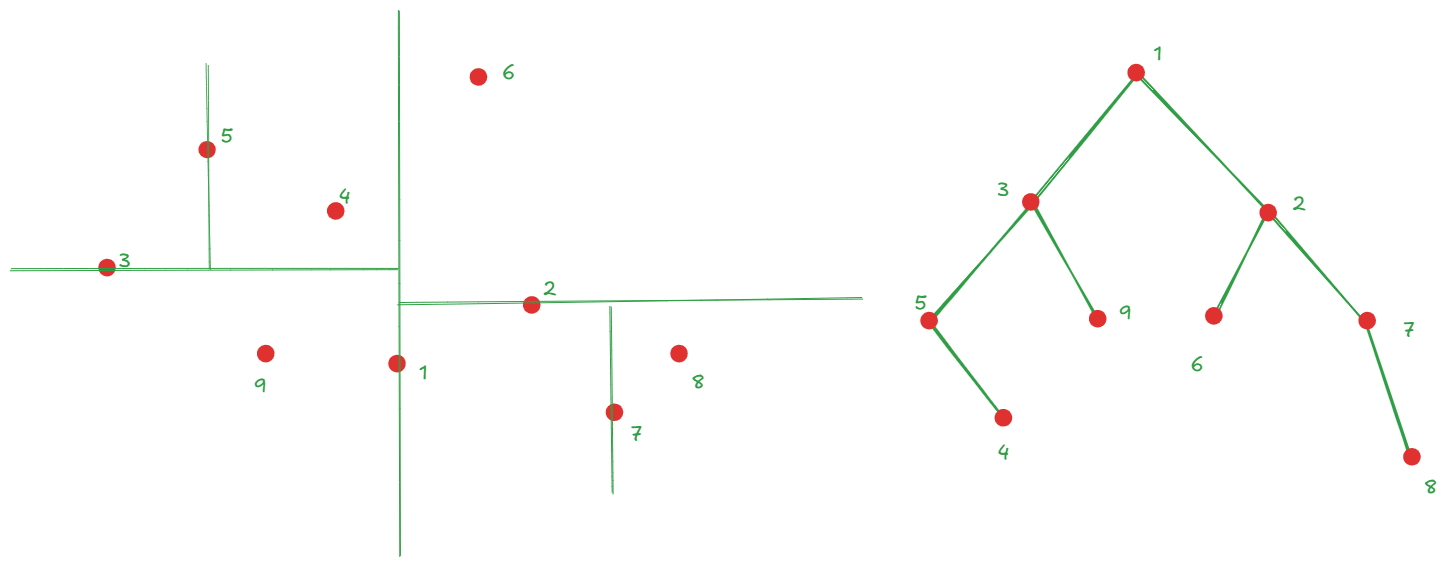

Nella figura a destra è mostrato il k-d tree costruito a partire dai punti rappresentati nella figura a sinistra.  
Il nodo radice è il punto mediano rispetto alle ascisse.  
Al livello successivo si cambia coordinata:  
- Il nodo `3` rappresenta il punto con ordinata mediana tra tutti quelli a sinistra della radice.  
- Il nodo `2` rappresenta il punto con ordinata mediana tra tutti quelli a destra della radice.  

Il processo continua allo stesso modo fino a suddividere lo spazio in regioni contenenti al massimo un punto.

Per costruire il k-d tree:  
- Serve ordinare i punti rispetto alla coordinata scelta per individuare il mediano.  
- Per ogni nuovo nodo, i punti vengono partizionati in due insiemi (sinistra/destra).  
- L’ordinamento richiede tempo O(n log n) per livello, mentre la partizione è lineare.  
- Con un albero bilanciato (altezza logaritmica), la costruzione richiede complessivamente O(n log² n).


### Ricerca

Per trovare i vicini di un punto `x` sull’albero, si parte dalla radice, confrontando la coordinata di riferimento del nodo corrente con quella di `x`. In base all’esito del confronto si scende nel figlio sinistro o nel figlio destro.  

Dopo circa $O(\log n)$ passi si raggiunge un nodo foglia.   A questo punto i `k` vicini più prossimi a `x` vengono cercati — sfruttando le proprietà geometriche del k-d tree — non solo nel percorso seguito, ma anche in un numero limitato di regioni vicine che potrebbero contenere punti più vicini di quelli già trovati.  

Questo consente di ridurre drasticamente il numero di nodi visitati rispetto alla ricerca esaustiva sull’intero insieme.  
Infatti, si può dimostrare che la parte aggiuntiva di ricerca nei sottoalberi “vicini” richiede tempo costante in media, garantendo così un costo medio della ricerca pari a $O(k \log n)$.

### Integrazione in KNN

Si utilizza la libreria `scipi`.
    

In [ ]:
from scipy.spatial import KDTree
import matplotlib.pyplot as plt 

Un esempio

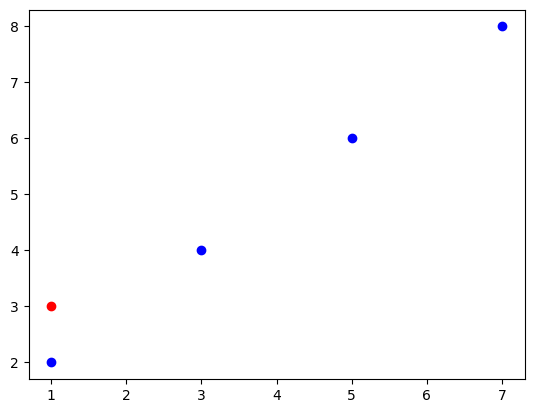

In [ ]:
points = [(1,2), (3,4), (5,6), (7,8)]
p = (1,3)

plt.scatter([x for x,y in points], [y for x,y in points], color='blue')
plt.scatter([p[0]], [p[1]], color='red')

In [ ]:
tree = KDTree(points)
dist, idx = tree.query(p)  # punto di query
print(points[idx], dist)

(1, 2) 1.0


In [ ]:
tree.query(p, k=2)

(array([1.        , 2.23606798]), array([0, 1]))

Ridefinizione della classe KNN

In [ ]:
def mode( a ):
    '''
    parametro: a, un array-like

    return: l'elemento più frequente ed il numero di occorrenze
    '''

    itms, cnts = np.unique(np.array(a), return_counts=True )

    return itms[np.argmax(cnts)], max(cnts)

class KNN(object):
    def __init__(self, k = 5):
        self.k = k
        self.X = None
        self.y = None
        self.tree = None
    
    def fit(self, X, y):
        self.X = X
        self.y = y
        self.tree = KDTree(self.X)
        
    def predict(self, x):        
        # Ottiene gli indici dei k punti più vicini
        _, k_indices = self.tree.query(x, k=self.k)
        
        # Prende le etichette corrispondenti
        return mode(self.y[k_indices])

Valutazione

In [ ]:
knn = KNN()
knn.fit(X_train, y_train)

preds = np.array([knn.predict(x)[0] for x in X_test]) == y_test
print('Accuratezza ', preds.sum()/preds.shape[0])

Accuratezza  0.9333333333333333


# Confronto: Liste Python vs NumPy ndarray

| Operazione                           | Lista Python (`list`)                          | NumPy `ndarray`                                | Complessità appross. |
|--------------------------------------|-----------------------------------------------|-----------------------------------------------|----------------------|
| Creazione                             | `[]`, `[1, 2, 3]`                            | `np.array([1, 2, 3])`, `np.arange(3,10)`                         | O(n)                 |
| Accesso per indice                     | `lst[i]`                                      | `arr[i]`                                      | O(1)                 |
| Assegnazione per indice                | `lst[i] = x`                                  | `arr[i] = x`                                  | O(1)                 |
| Aggiunta in coda (`append`)            | `lst.append(x)`                               | `np.append(arr, x)` (crea nuovo array)        | Lista: O(1); ndarray: O(n) |
| Rimozione dalla coda         | `lst.pop()`                                  | Non supportato direttamente, hanno dim fissa | Lista: O(1); ndarray: O(n) |
| Concatenazione                         | `lst1 + lst2`                                 | `np.concatenate((arr1, arr2))`               | O(n+m)               |
| Ripetizione                         | `lst * k`                                 | `np.tile(arr, k)`               | O(n*k)               |
| Slicing                                | `lst[a:b]` (copia)                            | `arr[a:b]` (vista, no copia)                  | Lista: O(k); ndarray: O(1) |
| Somma vettoriale                        | `[x+y for x,y in zip(l1,l2)]`                 | `arr1 + arr2` (broadcasting)                 | Lista: O(n); ndarray: O(n) più veloce |
| Moltiplicazione per scalare             | `[x*3 for x in lst]`                          | `arr * 3`                                     | O(n)                 |
